In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [2]:
class BatsmanSummary(TypedDict):

    runs: int
    balls: int
    fours: int
    sixes: int

    strike_rate: float
    bpb: float
    boundries_percentage: float
    summary: str

In [3]:
# 1-Calculating the Strike rate
def calculate_sr(state: BatsmanSummary)-> BatsmanSummary:
    
    runs = state['runs']
    balls = state['balls']

    sr = runs / balls * 100

    state['strike_rate'] = sr

    return {'strike_rate':sr}

# 2- Calculating Boundries per balls
def calculate_bpb(state: BatsmanSummary)-> BatsmanSummary:

    fours = state['fours']
    sixes = state['sixes']
    balls = state['balls']

    total_boundry = fours+sixes
    bpb =  balls / total_boundry

    return {'bpb':bpb}

# 3-Calculating Boundries Percentage
def calculate_boundry_percent(state: BatsmanSummary)-> BatsmanSummary:

    boundry_percentage = (((state['fours'] *4) + (state['sixes'] * 6)) / state['runs'])*100

    return {'boundries_percentage':boundry_percentage}

# 4-Creating Overall summary
def create_summary(state: BatsmanSummary)-> BatsmanSummary:

    summary = f"""Here are summary for {state['runs']} runs in {state['balls']} balls with {state['fours']} four's & {state['sixes']} Sixes;\n
        {'-'*50}\n
        Strike Rate: {state['strike_rate']}\n
        Boundries per Balls: {state['bpb']}\n
        Boundry Percentage: {state['boundries_percentage']}
    """

    return {'summary':summary}


## Workflow Diagram

<!-- To add a PNG image, use the syntax below -->
![Alt text](/home/prashant/Documents/gen-ai/LangGraph/parallel_workflow.png)

In [4]:
# Define Graph
graph = StateGraph(BatsmanSummary)

# add node
graph.add_node('calculate_sr',calculate_sr)
graph.add_node('balls_per_boundry',calculate_bpb)
graph.add_node('boundry_percent',calculate_boundry_percent)
graph.add_node('summary',create_summary)

# add edges
graph.add_edge(START, 'calculate_sr')
graph.add_edge(START, 'balls_per_boundry')
graph.add_edge(START, 'boundry_percent')

graph.add_edge('calculate_sr', 'summary')
graph.add_edge('balls_per_boundry', 'summary')
graph.add_edge('boundry_percent', 'summary')

graph.add_edge('summary',END)

# compile
workflow = graph.compile()

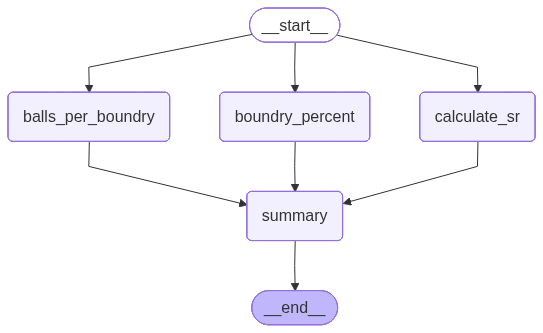

In [5]:
# Graph Diagram
workflow

In [7]:
# Execute

initial_state = {
    'runs':100,
    'balls':50,
    'fours':6,
    'sixes':4,
}

result = workflow.invoke(initial_state)

In [8]:
result

{'runs': 100,
 'balls': 50,
 'fours': 6,
 'sixes': 4,
 'strike_rate': 200.0,
 'bpb': 5.0,
 'boundries_percentage': 48.0,
 'summary': "Here are summary for 100 runs in 50 balls with 6 four's & 4 Sixes;\n\n        --------------------------------------------------\n\n        Strike Rate: 200.0\n\n        Boundries per Balls: 5.0\n\n        Boundry Percentage: 48.0\n    "}

In [10]:
print(f"Strike Rate: {result['strike_rate']}")
print(f"Boundries Per Balls: {result['bpb']}")
print(f"Boundries Percentage for overall {result['runs']}:{result['boundries_percentage']}\n\n")

print(f"Summary: \n\n{result['summary']}")

Strike Rate: 200.0
Boundries Per Balls: 5.0
Boundries Percentage for overall 100:48.0


Summary: 

Here are summary for 100 runs in 50 balls with 6 four's & 4 Sixes;

        --------------------------------------------------

        Strike Rate: 200.0

        Boundries per Balls: 5.0

        Boundry Percentage: 48.0
    
